In [1]:
"""
Part 3: 라벨 스무딩 (Label Smoothing)
- 라벨 스무딩의 효과
- 과신(Overconfidence) 방지
- 일반화 성능 향상

독립적으로 실행 가능합니다.
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# 라벨 스무딩 개념 이해

# 원래 레이블 (3개 클래스)
original_label = torch.tensor([1,0,0], dtype=torch.float)

original_label.numpy()
# 원래 레이블 (의미: 클래스 0번이 100% 정답)

array([1., 0., 0.], dtype=float32)

In [5]:
# 라벨 스무딩 적용
smoothing = 0.1
n_classes = 3

# smoothing formula
# y_smooth = y * (1-alpha) + alpha/K (클래스 수)

smooth_value = smoothing / n_classes
smooth_label = original_label * (1 - smoothing) + smooth_value

print(f'라벨 스무딩(alpha = {smoothing}) 적용')
print(smooth_label.numpy())

# 효과
# 모델이 100% 확인하지 않도록 햄(과신 overconfidence 방지)
# 왜 해요? 일반화 능력이 향상됨

라벨 스무딩(alpha = 0.1) 적용
[0.93333334 0.03333334 0.03333334]


In [18]:
# 라벨 스무딩 구현

class LabelSmoothingCrossEntropy(nn.Module):
    # 라벨스무딩이 적용된 교차엔트로피 손실
    def __init__(self, n_classes, smoothing=0.1):
        super().__init__()
        self.n_classes = n_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, pred, target):
        # log softmax
        log_probs = torch.log_softmax(pred, dim=1)
        # softmax가 확률로 변환 >> log를 취해서 교차 엔트로피 계산에 사용됨
        # dim=1 클래스 방향(열 방향)으로 softmax 적용
        # print(log_probs)
        # print(log_probs.shape) # [배치크기, 클래스 수]

        # target one-hot 변환
        # 스무딩 된 정답 분포 생성
        with torch.no_grad():
            # 기울기 추적 안함
            # 왜? true_dist (진짜 분포 distribution는 목표값 학습 파라미터가 아님)
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (self.n_classes - 1))
            # 모든 위치를 alpha(smoothing) / (K-1)로 채워줘
            # 왜 (K-1)? 정답 클래스 제외한 나머지에 균등 분배
            # 예) alpha=0.1, K=3 >> 0.1 / 2 = 0.05 (각 오답 클래스에)
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)

            # 정답 클래스 위치에 confidence(1-alpha) 값 배치
            # scatter_(dim, index, value): index 위치에 value 삽입
            # target.unsqueeze(1) : [배치] >> [배치, 1]
            # 예) target = [0,1] >> [[0],[1]] >> 각 행의 0번, 1번 열에 0.9 배치

        loss = torch.mean(torch.sum(-true_dist * log_probs, dim=1))
        return loss

        # P: 실제(정답) 분포 true_dist (label_smoothing 적용됨)
        # Q: 모델이 예측한 분포 softmax 확률 >> exp(log_probs)
        # cross entropy 변형
        # loss = -(sum(true_dist) * log_probs)
        # -(정답분포 * 예측로그확률)의 합
        # true_dist 높다면(정답) log_probs 낮으면 (예측 틀림) >> 손실이 큼
        # true_dist 높다면(정답) log_probs 높다면 (예측 맞음) >> 손실이 작음

        # KL Divergence 계산
        # 확률분포 2개가 있어요. 이 두개가 얼마나 다르지? (차이)가 있는지 확인하는 계산
        # 즉, 진짜 존재하는 분포(P), 모델이 예측한 분포(Q)
        # 모델이 예측한 분포(Q)가 얼마나 실제 분포(P)와 유사한가
        # Q가 P 에서 얼마나 벗어났나? 확인
        # CrossEntropyLoss = NLLLoss + KL Divergence

In [10]:
# 테스트

# 예측값
batch_logits =\
torch.tensor([
    [2.0, 0.5, 0.1],
    [0.3, 2.5, 0.2]
])

# 정답
batch_targets = torch.tensor([0, 1])

In [12]:
# 교차엔트로피 (Cross Entropy)

ce = nn.CrossEntropyLoss()
loss = ce(batch_logits, batch_targets)
loss.item()

0.25413817167282104

In [19]:
# 라벨스무딩 Cross Entropy
ce_smooth = LabelSmoothingCrossEntropy(n_classes=3, smoothing=0.1)
loss_smooth = ce_smooth(batch_logits, batch_targets)
loss_smooth.item()

0.4516381621360779

In [20]:
# 차이
(loss_smooth - loss).item()

0.19749999046325684

In [22]:
# 데이터 준비 및 모델 정의

# 5개의 클래스 분류 데이터
X, y = make_classification(
        n_samples=1000, n_features=20, n_informative=15,
        n_classes=5, n_clusters_per_class=1, random_state=42
        # n_clusters_per_class=1 각 클래스 당 군집 수 = 1개
    )

In [23]:
# 학습/테스트 데이터 분할

X_train, X_test, y_train, y_test =\
train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [34]:
# 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 텐서로 변환
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)

X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

print(X_train_t.shape)
print(X_test.shape)

torch.Size([800, 20])
(200, 20)


In [35]:
# 분류 모델 정의
class Classifier(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.network(x)


In [36]:
# 일반 vs 라벨 스무딩 학습 비교
smoothing_values = [0.0, 0.05, 0.1, 0.2]
results = {}

for smoothing in smoothing_values:
    if smoothing == 0.0:
        print(f'라벨스무딩 없음')
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = LabelSmoothingCrossEntropy(n_classes=5, smoothing=smoothing)

    # 모델 초기화
    model = Classifier(n_classes=5)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 학습
    train_losses = []
    train_accs = []

    num_epochs = 100
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        output = model(X_train_t)
        loss = criterion(output, y_train_t)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # 훈련 정확도
        with torch.no_grad():
            train_pred = torch.argmax(output, dim=1)
            train_acc = accuracy_score(y_train, train_pred.numpy())
            train_accs.append(train_acc)

    # 테스트
    model.eval()
    with torch.no_grad():
        test_output = model(X_test_t)
        test_pred = torch.argmax(test_output, dim=1)
        test_probs = torch.softmax(test_output, dim=1)

        test_acc = accuracy_score(y_test, test_pred.numpy())

        # 예측 확신도(최대 확률 평균)
        max_probs = torch.max(test_probs, dim=1)[0]
        avg_confidence = max_probs.mean().item()

    results[smoothing] = {
        'train_losses': train_losses,
        'train_accs' : train_accs,
        'test_acc' : test_acc,
        'avg_confidence' : avg_confidence,
        'test_probs' : test_probs
        }

    print(f'최종 훈련 손실: {train_losses[-1]:.4f}')
    print(f'최종 훈련 정확도: {train_accs[-1]:.4f}')
    print(f'테스트 정확도: {test_acc:.4f}')
    print(f'평균 확신도: {avg_confidence:.4f}')

라벨스무딩 없음
최종 훈련 손실: 0.3881
최종 훈련 정확도: 0.8738
테스트 정확도: 0.8650
평균 확신도: 0.8324
최종 훈련 손실: 0.6150
최종 훈련 정확도: 0.8688
테스트 정확도: 0.8550
평균 확신도: 0.7747
최종 훈련 손실: 0.7784
최종 훈련 정확도: 0.8725
테스트 정확도: 0.8800
평균 확신도: 0.7243
최종 훈련 손실: 1.0149
최종 훈련 정확도: 0.8875
테스트 정확도: 0.8750
평균 확신도: 0.6401


In [37]:
smoothing_values

[0.0, 0.05, 0.1, 0.2]

In [39]:
# results[smoothing]

In [53]:
# 성능 요약
print('성능 요약\n')
print(f'{'Alpha':>11} {'Train_acc':>13}{'Test_acc':>12}{'Confidence':>12}')
for smoothing in smoothing_values:
    result = results[smoothing]
    print(f'{smoothing:10.2f} {result['train_accs'][-1]:12.4f}'
          f'{result['test_acc']:12.4f} {result['avg_confidence']:12.4f}'

    )

성능 요약

      Alpha     Train_acc    Test_acc  Confidence
      0.00       0.8738      0.8650       0.8324
      0.05       0.8688      0.8550       0.7747
      0.10       0.8725      0.8800       0.7243
      0.20       0.8875      0.8750       0.6401


In [ ]:
# 오 놀라와라 (관찰)
# 1. 라벨스무딩 사용 시 테스트 정확도 향상 가능
# 2. 평균 확신도는 감소(과신 방지)
# 3. alpha 가 너무 크면 (0.2) 성능 저하 가능

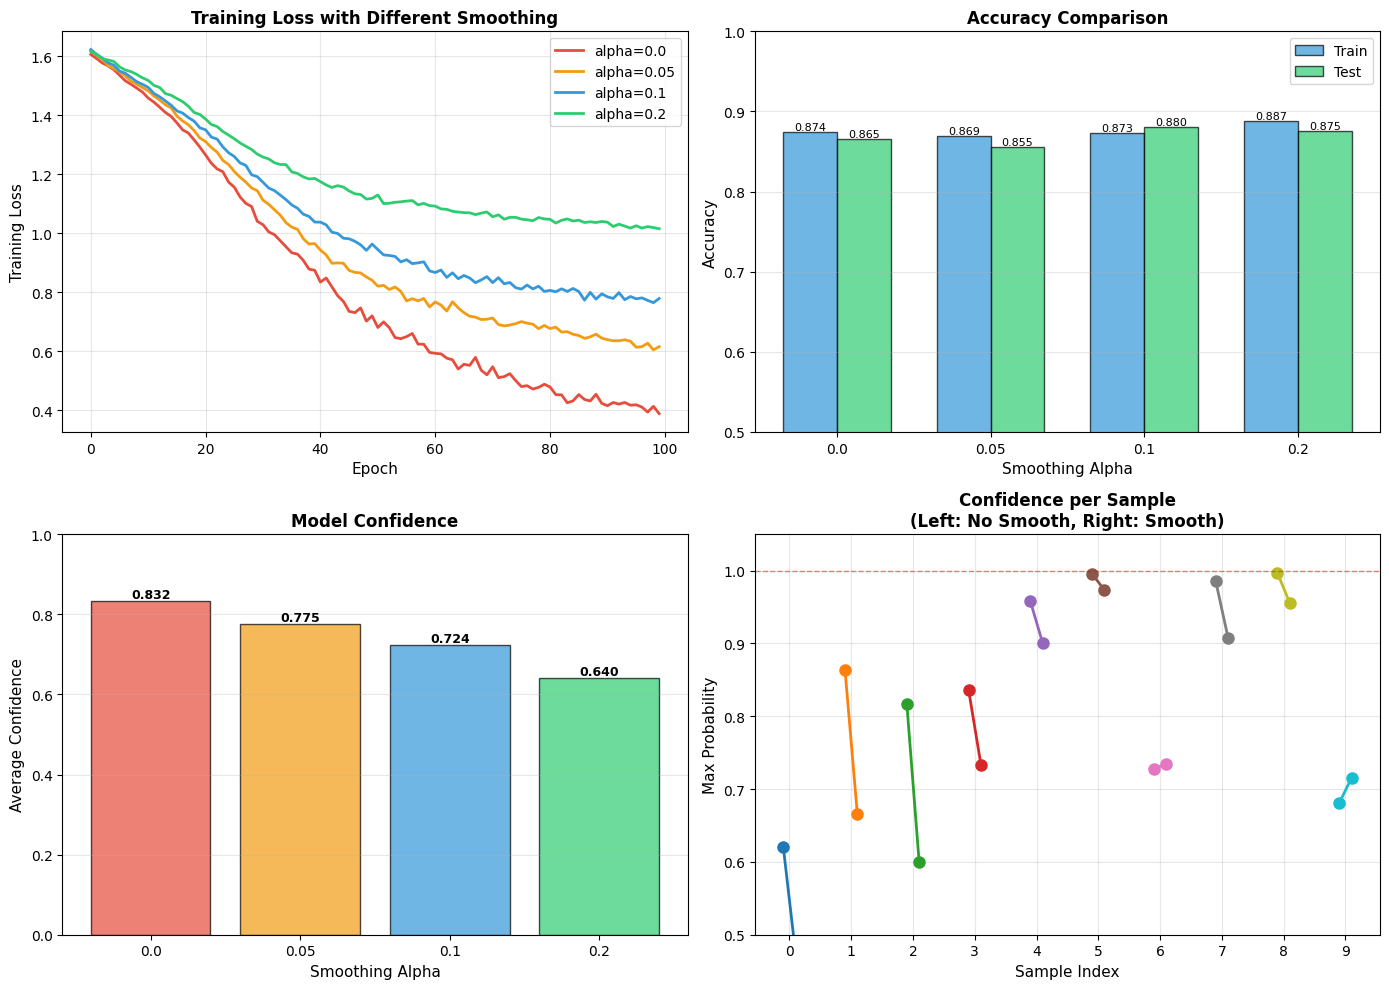


저장: part3_label_smoothing.png


In [54]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 학습 곡선 비교
ax1 = axes[0, 0]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
for smoothing, color in zip(smoothing_values, colors):
    losses = results[smoothing]['train_losses']
    ax1.plot(losses, label=f'alpha={smoothing}', linewidth=2, color=color)

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Training Loss', fontsize=11)
ax1.set_title('Training Loss with Different Smoothing',
              fontsize=12, weight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. 정확도 비교
ax2 = axes[0, 1]
train_accs_final = [results[s]['train_accs'][-1] for s in smoothing_values]
test_accs = [results[s]['test_acc'] for s in smoothing_values]

x_pos = np.arange(len(smoothing_values))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, train_accs_final, width,
                label='Train', color='#3498db', edgecolor='black', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, test_accs, width,
                label='Test', color='#2ecc71', edgecolor='black', alpha=0.7)

ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Accuracy Comparison', fontsize=12, weight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{s}' for s in smoothing_values])
ax2.set_xlabel('Smoothing Alpha', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0.5, 1.0)

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 3. 확신도 비교
ax3 = axes[1, 0]
confidences = [results[s]['avg_confidence'] for s in smoothing_values]

bars = ax3.bar([f'{s}' for s in smoothing_values], confidences,
               color=colors, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Smoothing Alpha', fontsize=11)
ax3.set_ylabel('Average Confidence', fontsize=11)
ax3.set_title('Model Confidence', fontsize=12, weight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 1.0)

# 값 표시
for bar, conf in zip(bars, confidences):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{conf:.3f}', ha='center', va='bottom', fontsize=9, weight='bold')

# 4. 확률 분포 비교 (첫 10개 샘플)
ax4 = axes[1, 1]

# alpha=0.0과 alpha=0.1 비교
probs_no_smooth = results[0.0]['test_probs'][:10].numpy()
probs_smooth = results[0.1]['test_probs'][:10].numpy()

sample_indices = range(10)
for i in sample_indices:
    max_prob_no = probs_no_smooth[i].max()
    max_prob_smooth = probs_smooth[i].max()

    ax4.plot([i-0.1, i+0.1], [max_prob_no, max_prob_smooth],
             'o-', linewidth=2, markersize=8)

ax4.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('Sample Index', fontsize=11)
ax4.set_ylabel('Max Probability', fontsize=11)
ax4.set_title('Confidence per Sample\n(Left: No Smooth, Right: Smooth)',
              fontsize=12, weight='bold')
ax4.set_xticks(sample_indices)
ax4.grid(alpha=0.3)
ax4.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()
plt.savefig('part3_label_smoothing.png', dpi=150, bbox_inches='tight')
print("\n저장: part3_label_smoothing.png")
plt.close()

In [ ]:
# 모델확신도가 떨어졌다고 해서 나쁜 것이 아니예요
# 덜 확신해도 더 정확한 (test 결과가 제일 좋은) 모델이 좋은거예요

최종 요약

In [55]:
# 최종 요약

print("\n핵심 개념:")
print("\n1. 라벨 스무딩")
print("   - 정답 레이블을 부드럽게 만듦")
print("   - [1, 0, 0] -> [0.93, 0.03, 0.03]")
print("   - 과신(Overconfidence) 방지")

print("\n2. 효과")
print("   - 일반화 성능 향상")
print("   - 과적합 방지")
print("   - 모델 캘리브레이션 개선")

print("\n3. 하이퍼파라미터")
print("   - alpha = 0.0: 스무딩 없음")
print("   - alpha = 0.1: 표준 설정 (권장)")
print("   - alpha = 0.2: 강한 스무딩 (주의)")

print("\n실전 가이드:")
print("  - 대규모 데이터셋: alpha=0.1")
print("  - 작은 데이터셋: 사용 안 함 또는 alpha=0.05")
print("  - 과적합 문제: alpha=0.1~0.15")
print("  - PyTorch 1.10+: label_smoothing 파라미터 사용")

print("\n생성된 파일:")
print("  part3_label_smoothing.png - 라벨 스무딩 효과")


핵심 개념:

1. 라벨 스무딩
   - 정답 레이블을 부드럽게 만듦
   - [1, 0, 0] -> [0.93, 0.03, 0.03]
   - 과신(Overconfidence) 방지

2. 효과
   - 일반화 성능 향상
   - 과적합 방지
   - 모델 캘리브레이션 개선

3. 하이퍼파라미터
   - alpha = 0.0: 스무딩 없음
   - alpha = 0.1: 표준 설정 (권장)
   - alpha = 0.2: 강한 스무딩 (주의)

실전 가이드:
  - 대규모 데이터셋: alpha=0.1
  - 작은 데이터셋: 사용 안 함 또는 alpha=0.05
  - 과적합 문제: alpha=0.1~0.15
  - PyTorch 1.10+: label_smoothing 파라미터 사용

생성된 파일:
  part3_label_smoothing.png - 라벨 스무딩 효과
